In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

In [2]:
# Load dataset
df = pd.read_csv('/content/Medical_appointment_data.csv')
df.head(10)

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,1,23.18,0.00,27.5,0.0,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,1,14.31,0.02,16.5,0.6,1,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,1,21.61,0.01,29.9,0.2,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,1,21.39,0.11,24.1,1.4,1,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,0,20.15,0.02,23.1,0.2,1,1,no_rain,mild,2020-01-01,0,0,0,0,0,0
5,psychotherapy,13,M,no,intellectual,ITAJAÍ,afternoon,9.0,1,0,1,18.92,0.00,20.8,0.0,1,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
6,speech therapy,10,F,yes,motor,ITAJAÍ,morning,NaN,0,0,0,23.83,0.02,27.5,0.6,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
7,physiotherapy,7,M,no,motor,ITAJAÍ,morning,7.0,1,0,1,17.54,0.00,24.6,0.0,1,1,no_rain,mild,2020-01-01,0,0,0,0,0,1
8,physiotherapy,16,M,yes,motor,Stokesfort,afternoon,18.0,0,0,0,22.95,0.00,26.1,0.0,1,1,no_rain,mild,2020-01-01,0,0,0,0,0,0
9,occupational therapy,16,F,no,intellectual,ITAJAÍ,afternoon,NaN,0,0,0,16.77,0.19,19.8,3.2,1,1,moderate,cold,2020-01-01,0,0,0,0,0,0


In [3]:
# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
missing = df.isnull().mean() * 100
print("\nMissing %:\n", missing.sort_values(ascending=False))

# Unique values
print("\nUnique values:\n", df.nunique())

# Duplicat data
print("\nDuplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Shape: (109593, 26)

Data Types:
 specialty                       object
appointment_time                 int64
gender                          object
no_show                         object
disability                      object
place                           object
appointment_shift               object
age                            float64
under_12_years_old               int64
over_60_years_old                int64
patient_needs_companion          int64
average_temp_day               float64
average_rain_day               float64
max_temp_day                   float64
max_rain_day                   float64
rainy_day_before                 int64
storm_day_before                 int64
rain_intensity                  object
heat_intensity                  object
appointment_date_continuous     object
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
Scholarship                   

In [4]:
print("Unique values for 'specialty':", df['specialty'].unique())
print("Unique values for 'rain_intensity':", df['rain_intensity'].unique())
print("Unique values for 'heat_intensity':", df['heat_intensity'].unique())
print("Unique values for 'gender':", df['gender'].unique())
print("Unique values for 'appointment_shift':",df['appointment_shift'].unique())
print("Unique values for 'place':",df['place'].unique())
print("Unique values for 'disability':",df['disability'].unique())
print("Unique values for 'no_show':",df['no_show'].unique())

Unique values for 'specialty': ['psychotherapy' nan 'speech therapy' 'physiotherapy'
 'occupational therapy' 'assist' 'pedagogo' 'enf' 'sem especialidade']
Unique values for 'rain_intensity': ['no_rain' 'moderate' 'weak' 'heavy']
Unique values for 'heat_intensity': ['warm' 'cold' 'mild' 'heavy_warm' 'heavy_cold']
Unique values for 'gender': ['F' 'M' 'I']
Unique values for 'appointment_shift': ['afternoon' 'morning']
Unique values for 'place': ['Lake Marvinville' 'ITAPEMA' 'ITAJAÍ' ... 'West Gregoryport'
 'Reynoldsville' 'Wilcoxstad']
Unique values for 'disability': ['intellectual' 'motor' nan ' ']
Unique values for 'no_show': ['yes' 'no']


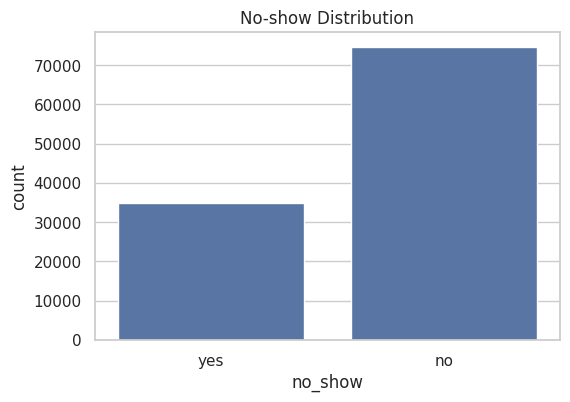

no_show
no     68.207417
yes    31.792583
Name: proportion, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='no_show', data=df)
plt.title("No-show Distribution")
plt.show()

# Percentage
print(df['no_show'].value_counts(normalize=True) * 100)

In [6]:
df.describe()

,appointment_time,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
count,109557.000000,86628.000000,109557.000000,109557.000000,109557.000000,107366.000000,107332.000000,107350.000000,107314.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000
mean,12.121517,18.632544,0.446544,0.071351,0.519967,20.346708,0.183558,24.032954,2.048325,0.937558,0.937695,0.058107,0.023960,0.018547,0.009119,0.055122,0.311847
std,3.281433,17.667387,0.497136,0.257411,0.499603,3.446024,0.416292,3.959818,4.352513,0.241958,0.241711,0.233946,0.152926,0.134921,0.095055,0.228219,0.463250
min,7.000000,2.000000,0.000000,0.000000,0.000000,8.940000,0.000000,13.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,8.000000,0.000000,0.000000,0.000000,18.060000,0.000000,21.400000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,12.000000,0.000000,0.000000,1.000000,20.600000,0.010000,23.900000,0.200000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.000000,18.000000,1.000000,0.000000,1.000000,22.720000,0.150000,26.800000,1.900000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,18.000000,110.000000,1.000000,1.000000,1.000000,28.010000,4.770000,35.400000,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


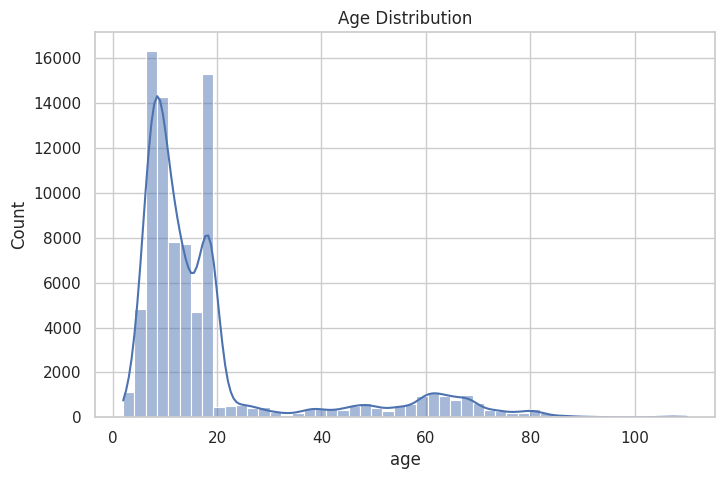

In [7]:
#Feature Understanding(Age Distribution)

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=50, kde=True)
plt.title("Age Distribution")
plt.show()

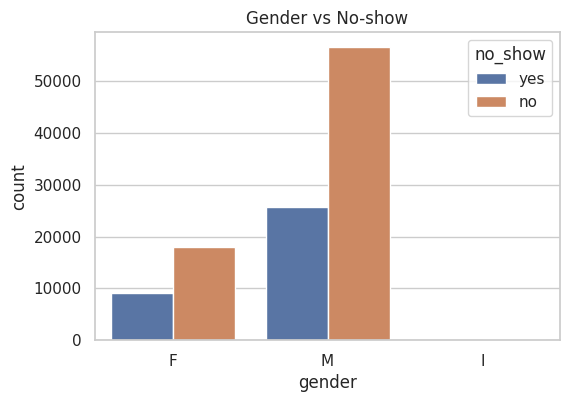

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='no_show', data=df)
plt.title("Gender vs No-show")
plt.show()

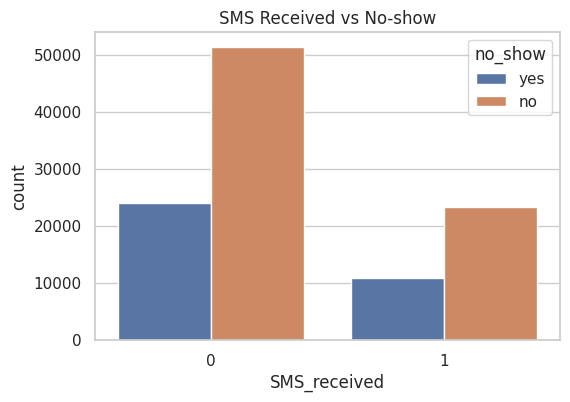

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='SMS_received', hue='no_show', data=df)
plt.title("SMS Received vs No-show")
plt.show()

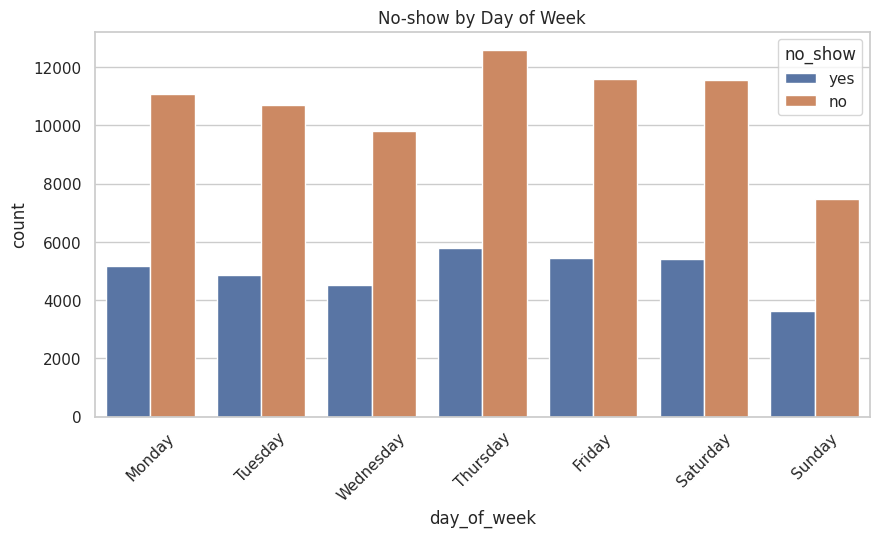

In [10]:
# Convert to datetime
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'], errors='coerce')

# Extract day
df['day_of_week'] = df['appointment_date_continuous'].dt.day_name()

plt.figure(figsize=(10,5))
sns.countplot(x='day_of_week', hue='no_show', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.xticks(rotation=45)
plt.title("No-show by Day of Week")
plt.show()

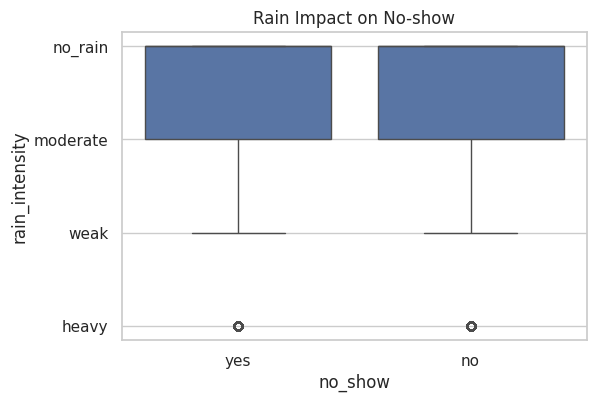

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='no_show', y='rain_intensity', data=df)
plt.title("Rain Impact on No-show")
plt.show()

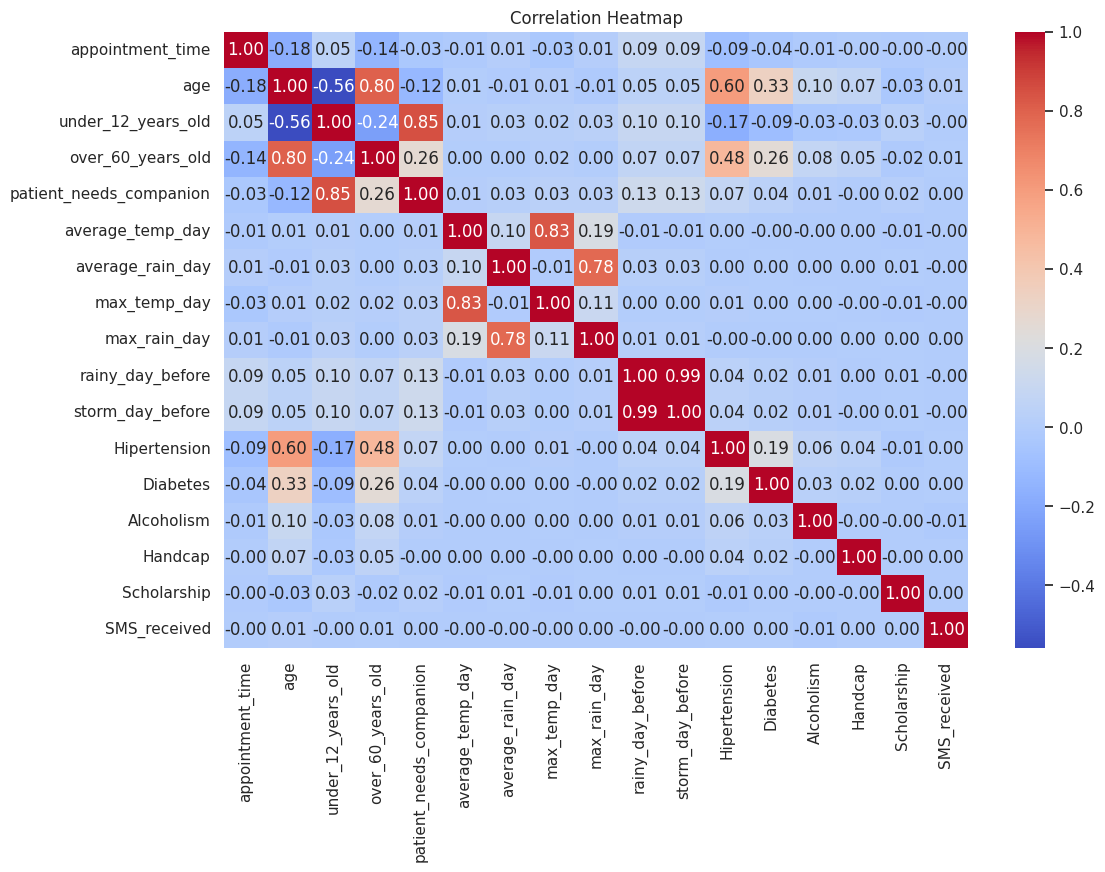

In [12]:
# Correlation Heatmap (Numeric Only)

plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Make a copy to avoid modifying the original correlation matrix during analysis
corr_matrix_analysis = corr.copy()

# Fill diagonal with NaN to exclude self-correlations (correlation of a variable with itself is always 1)
np.fill_diagonal(corr_matrix_analysis.values, np.nan)

# Find the strongest positive correlation
strongest_positive = corr_matrix_analysis.max().max()
strongest_positive_loc = corr_matrix_analysis.stack().idxmax()

# Find the strongest negative correlation
strongest_negative = corr_matrix_analysis.min().min()
strongest_negative_loc = corr_matrix_analysis.stack().idxmin()

print(f"Strongest Positive Correlation: {strongest_positive:.2f} between {strongest_positive_loc}")
print(f"Strongest Negative Correlation: {strongest_negative:.2f} between {strongest_negative_loc}")

Strongest Positive Correlation: 0.99 between ('rainy_day_before', 'storm_day_before')
Strongest Negative Correlation: -0.56 between ('age', 'under_12_years_old')


ADVANCED EDA

In [14]:
# Convert target to binary
# Map 'no' to 0 and 'yes' to 1
df['no_show'] = df['no_show'].map({'no': 0, 'yes': 1})
df.head(5)

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,day_of_week
0,psychotherapy,17,F,1,intellectual,Lake Marvinville,afternoon,9.0,1,0,1,23.18,0.00,27.5,0.0,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0,Wednesday
1,NaN,7,M,0,intellectual,ITAPEMA,morning,11.0,1,0,1,14.31,0.02,16.5,0.6,1,1,no_rain,cold,2020-01-01,0,0,0,0,0,0,Wednesday
2,speech therapy,16,M,0,intellectual,ITAJAÍ,afternoon,8.0,1,0,1,21.61,0.01,29.9,0.2,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0,Wednesday
3,speech therapy,14,M,1,intellectual,Sarahside,afternoon,9.0,1,0,1,21.39,0.11,24.1,1.4,1,1,moderate,mild,2020-01-01,0,0,0,0,0,1,Wednesday
4,physiotherapy,8,M,0,motor,ITAJAÍ,morning,NaN,0,0,0,20.15,0.02,23.1,0.2,1,1,no_rain,mild,2020-01-01,0,0,0,0,0,0,Wednesday


In [15]:
# TIME FEATURE ENGINEERING

df['appointment_date'] = pd.to_datetime(df['appointment_date_continuous'])

df['day_of_week'] = df['appointment_date'].dt.day_name()
df['month'] = df['appointment_date'].dt.month
df['week'] = df['appointment_date'].dt.isocalendar().week
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

NO-SHOW ANALYSIS

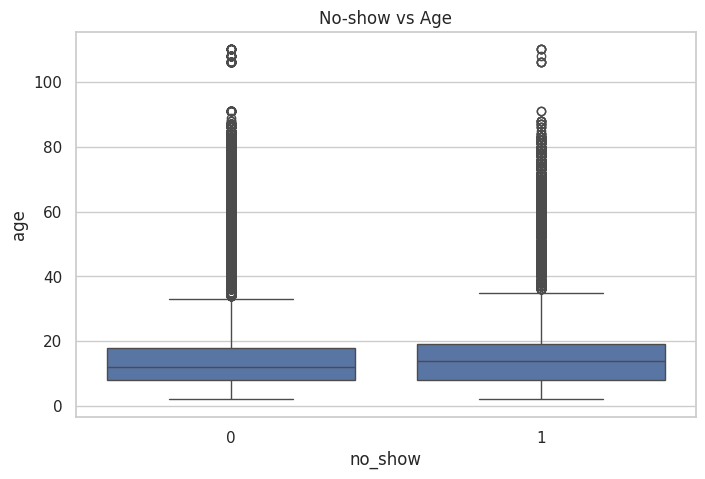

In [16]:
# By Age

plt.figure(figsize=(8,5))
sns.boxplot(x='no_show', y='age', data=df)
plt.title("No-show vs Age")
plt.show()

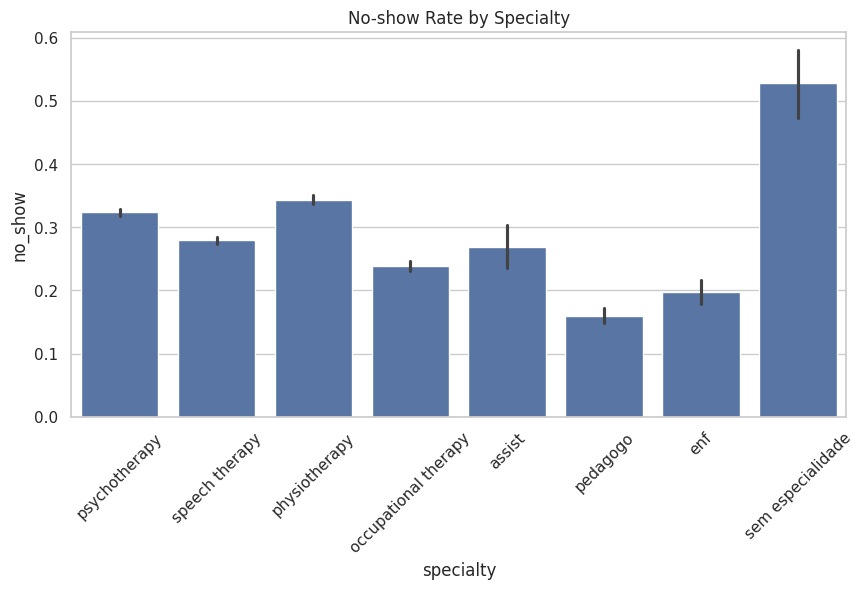

In [17]:
# Specialty Impact

plt.figure(figsize=(10,5))
sns.barplot(x='specialty', y='no_show', data=df)
plt.xticks(rotation=45)
plt.title("No-show Rate by Specialty")
plt.show()

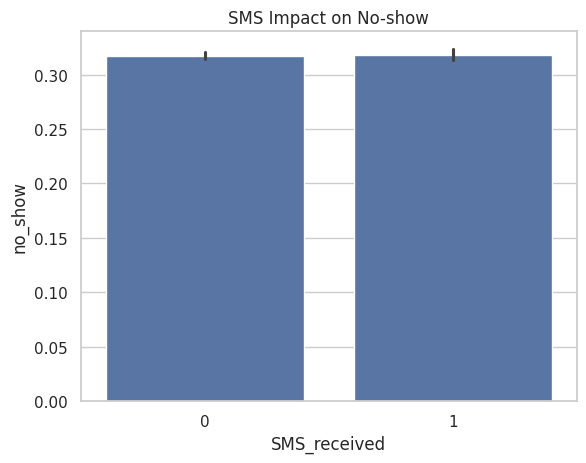

In [18]:
# SMS Impact

sns.barplot(x='SMS_received', y='no_show', data=df)
plt.title("SMS Impact on No-show")
plt.show()

In [19]:
pd.crosstab(df['SMS_received'], df['no_show'], normalize='index')

no_show,0,1
SMS_received,,
0,0.682380,0.317620
1,0.681399,0.318601


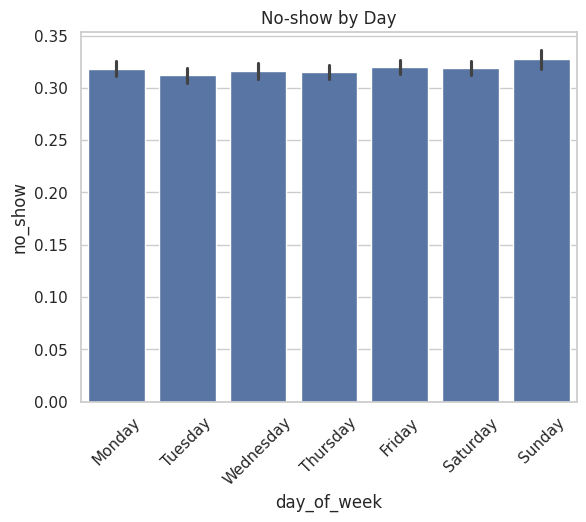

In [20]:
# Day of Week

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.barplot(x='day_of_week', y='no_show', data=df, order=order)
plt.xticks(rotation=45)
plt.title("No-show by Day")
plt.show()

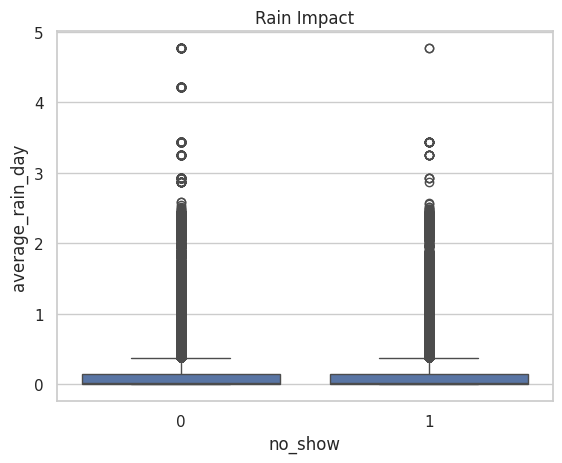

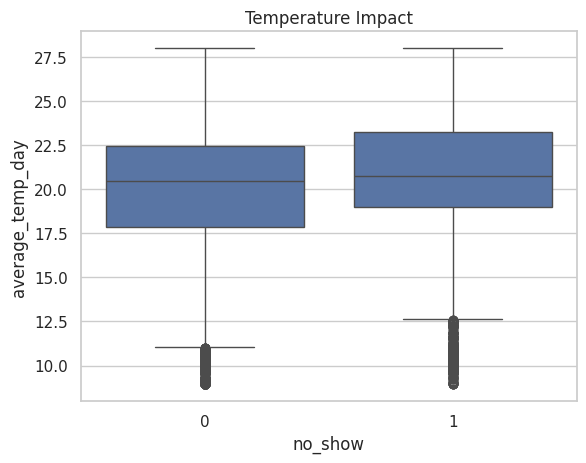

In [21]:
# WEATHER IMPACT

sns.boxplot(x='no_show', y='average_rain_day', data=df)
plt.title("Rain Impact")
plt.show()

sns.boxplot(x='no_show', y='average_temp_day', data=df)
plt.title("Temperature Impact")
plt.show()

**DEMAND ANALYSIS (CRITICAL FOR FORECASTING)**

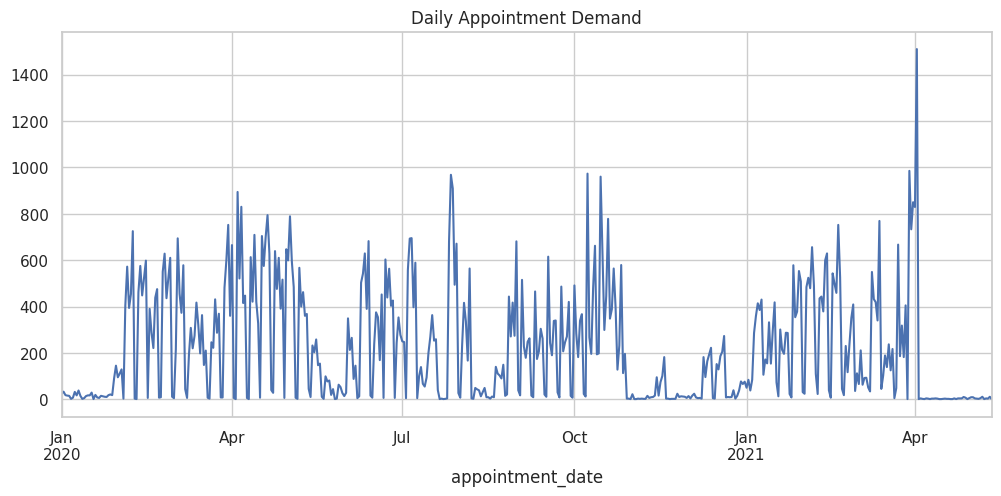

In [22]:
# Daily Demand

daily = df.groupby('appointment_date').size()

plt.figure(figsize=(12,5))
daily.plot()
plt.title("Daily Appointment Demand")
plt.show()

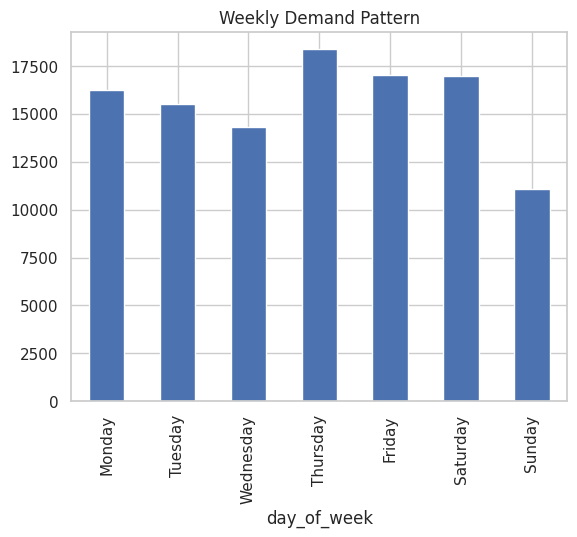

In [23]:
# Weekly Seasonality

weekly = df.groupby('day_of_week').size().reindex(order)

weekly.plot(kind='bar')
plt.title("Weekly Demand Pattern")
plt.show()

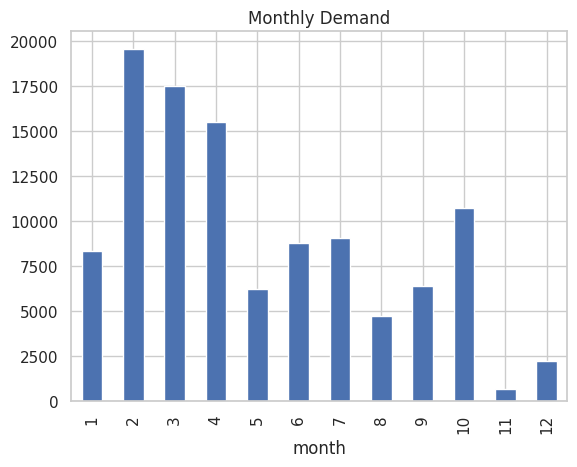

In [24]:
# Monthly Trend

monthly = df.groupby('month').size()

monthly.plot(kind='bar')
plt.title("Monthly Demand")
plt.show()

**PREPROCESSING**

In [25]:
# COPY DATA (SAFE PRACTICE)

df_model = df.copy()

In [26]:
# MISSING VALUES
# Age & Categorical Columns
df_model['age'] = df_model['age'].fillna(df_model['age'].median())
df_model['specialty'] = df_model['specialty'].fillna(df_model['specialty'].mode()[0])
df_model['disability'] = df_model['disability'].fillna(df_model['disability'].mode()[0])
df_model['place'] = df_model['place'].fillna(df_model['place'].mode()[0])
df_model['average_temp_day'] = df_model['average_temp_day'].fillna(df_model['average_temp_day'].mode()[0])
df_model['average_rain_day'] = df_model['average_rain_day'].fillna(df_model['average_rain_day'].mode()[0])
df_model['max_temp_day'] = df_model['max_temp_day'].fillna(df_model['max_temp_day'].mode()[0])
df_model['max_rain_day'] = df_model['max_rain_day'].fillna(df_model['max_rain_day'].mode()[0])

In [27]:
df_model['appointment_date'] = pd.to_datetime(df_model['appointment_date_continuous'])

df_model['day_of_week'] = df_model['appointment_date'].dt.dayofweek
df_model['month'] = df_model['appointment_date'].dt.month
df_model['week'] = df_model['appointment_date'].dt.isocalendar().week.astype(int)

df_model['is_weekend'] = (df_model['day_of_week'] >= 5).astype(int)

# Days since first record (important for trend)
df_model['days_since_start'] = (df_model['appointment_date'] - df_model['appointment_date'].min()).dt.days


In [28]:
df_model.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,day_of_week,appointment_date,month,week,is_weekend,days_since_start
0,psychotherapy,17,F,1,intellectual,Lake Marvinville,afternoon,9.0,1,0,1,23.18,0.00,27.5,0.0,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0,2,2020-01-01,1,1,0,0
1,psychotherapy,7,M,0,intellectual,ITAPEMA,morning,11.0,1,0,1,14.31,0.02,16.5,0.6,1,1,no_rain,cold,2020-01-01,0,0,0,0,0,0,2,2020-01-01,1,1,0,0
2,speech therapy,16,M,0,intellectual,ITAJAÍ,afternoon,8.0,1,0,1,21.61,0.01,29.9,0.2,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0,2,2020-01-01,1,1,0,0
3,speech therapy,14,M,1,intellectual,Sarahside,afternoon,9.0,1,0,1,21.39,0.11,24.1,1.4,1,1,moderate,mild,2020-01-01,0,0,0,0,0,1,2,2020-01-01,1,1,0,0
4,physiotherapy,8,M,0,motor,ITAJAÍ,morning,12.0,0,0,0,20.15,0.02,23.1,0.2,1,1,no_rain,mild,2020-01-01,0,0,0,0,0,0,2,2020-01-01,1,1,0,0


**FEATURE ENGINEERING**

In [29]:
# age group
df_model['age_group'] = pd.cut(df_model['age'],
                              bins=[0,12,18,40,60,100],
                              labels=['child','teen','adult','middle','senior'])

In [30]:
# Health Score

df_model['health_score'] = (
    df_model['Hipertension'] +
    df_model['Diabetes'] +
    df_model['Alcoholism'] +
    df_model['Handcap']
)

In [31]:
df_model['waiting_days'] = (
    df_model['appointment_date'] -
    df_model['appointment_date'].min()
).dt.days

In [32]:
df_model['time_shift_combo'] = (
    df_model['appointment_time'].astype(str) + "_" +
    df_model['appointment_shift'].astype(str)
)

In [33]:
df_model['bad_weather'] = (
    (df_model['rainy_day_before'] == 1) |
    (df_model['storm_day_before'] == 1)
).astype(int)

In [34]:
df_model['high_risk_patient'] = (
    (df_model['age'] < 25) &
    (df_model['health_score'] == 0)
).astype(int)

In [35]:
daily_counts = df_model.groupby('appointment_date').size()
df_model['daily_load'] = df_model['appointment_date'].map(daily_counts)

In [36]:
# Interaction Features

# Age × health
df_model['age_health_interaction'] = df_model['age'] * df_model['health_score']

# Weather stress
df_model['weather_stress'] = df_model['average_temp_day'] * df_model['average_rain_day']

In [37]:
# Frequency Encoding for place
place_freq = df_model['place'].value_counts(normalize=True)
df_model['place_freq'] = df_model['place'].map(place_freq)

In [38]:
df_model.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,day_of_week,appointment_date,month,week,is_weekend,days_since_start,age_group,health_score,waiting_days,time_shift_combo,bad_weather,high_risk_patient,daily_load,age_health_interaction,weather_stress,place_freq
0,psychotherapy,17,F,1,intellectual,Lake Marvinville,afternoon,9.0,1,0,1,23.18,0.00,27.5,0.0,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0,2,2020-01-01,1,1,0,0,child,0,0,17_afternoon,1,1,25,0.0,0.0000,0.000009
1,psychotherapy,7,M,0,intellectual,ITAPEMA,morning,11.0,1,0,1,14.31,0.02,16.5,0.6,1,1,no_rain,cold,2020-01-01,0,0,0,0,0,0,2,2020-01-01,1,1,0,0,child,0,0,7_morning,1,1,25,0.0,0.2862,0.024325
2,speech therapy,16,M,0,intellectual,ITAJAÍ,afternoon,8.0,1,0,1,21.61,0.01,29.9,0.2,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0,2,2020-01-01,1,1,0,0,child,0,0,16_afternoon,1,1,25,0.0,0.2161,0.292277
3,speech therapy,14,M,1,intellectual,Sarahside,afternoon,9.0,1,0,1,21.39,0.11,24.1,1.4,1,1,moderate,mild,2020-01-01,0,0,0,0,0,1,2,2020-01-01,1,1,0,0,child,0,0,14_afternoon,1,1,25,0.0,2.3529,0.000091
4,physiotherapy,8,M,0,motor,ITAJAÍ,morning,12.0,0,0,0,20.15,0.02,23.1,0.2,1,1,no_rain,mild,2020-01-01,0,0,0,0,0,0,2,2020-01-01,1,1,0,0,child,0,0,8_morning,1,1,25,0.0,0.4030,0.292277


In [39]:
drop_cols = [
 'under_12_years_old',
 'over_60_years_old',
 'week',
 'month',
 'place',
 'days_since_start'

]

df_model.drop(columns=drop_cols, inplace=True)

In [40]:
final_features = [
 'specialty',
 'appointment_time',
 'appointment_shift',
 'age',
 'patient_needs_companion',
 'SMS_received',
 'day_of_week',
 'is_weekend',
 'health_score',
 'age_health_interaction',
 'weather_stress',
 'waiting_days',
 'bad_weather',
 'high_risk_patient',
 'daily_load'
 'place_freq'
]

In [41]:
df_model


,specialty,appointment_time,gender,no_show,disability,appointment_shift,age,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,day_of_week,appointment_date,is_weekend,age_group,health_score,waiting_days,time_shift_combo,bad_weather,high_risk_patient,daily_load,age_health_interaction,weather_stress,place_freq
0,psychotherapy,17,F,1,intellectual,afternoon,9.0,1,23.18,0.00,27.5,0.0,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0,2,2020-01-01,0,child,0,0,17_afternoon,1,1,25,0.0,0.0000,0.000009
1,psychotherapy,7,M,0,intellectual,morning,11.0,1,14.31,0.02,16.5,0.6,1,1,no_rain,cold,2020-01-01,0,0,0,0,0,0,2,2020-01-01,0,child,0,0,7_morning,1,1,25,0.0,0.2862,0.024325
2,speech therapy,16,M,0,intellectual,afternoon,8.0,1,21.61,0.01,29.9,0.2,1,1,no_rain,warm,2020-01-01,0,0,0,0,0,0,2,2020-01-01,0,child,0,0,16_afternoon,1,1,25,0.0,0.2161,0.292277
3,speech therapy,14,M,1,intellectual,afternoon,9.0,1,21.39,0.11,24.1,1.4,1,1,moderate,mild,2020-01-01,0,0,0,0,0,1,2,2020-01-01,0,child,0,0,14_afternoon,1,1,25,0.0,2.3529,0.000091
4,physiotherapy,8,M,0,motor,morning,12.0,0,20.15,0.02,23.1,0.2,1,1,no_rain,mild,2020-01-01,0,0,0,0,0,0,2,2020-01-01,0,child,0,0,8_morning,1,1,25,0.0,0.4030,0.292277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109588,psychotherapy,16,M,1,intellectual,afternoon,18.0,0,18.97,0.00,25.6,0.0,1,1,no_rain,mild,2021-05-11,0,0,0,0,0,0,1,2021-05-11,0,teen,0,496,16_afternoon,1,1,11,0.0,0.0000,0.292277
109589,speech therapy,9,F,1,motor,morning,18.0,0,24.46,0.23,31.4,8.7,1,1,moderate,warm,2021-05-11,0,0,0,0,0,0,1,2021-05-11,0,teen,0,496,9_morning,1,1,11,0.0,5.6258,0.000027
109590,psychotherapy,13,F,0,intellectual,afternoon,8.0,1,20.88,0.00,23.8,5.1,1,1,moderate,mild,2021-05-11,0,0,0,0,0,1,1,2021-05-11,0,child,0,496,13_afternoon,1,1,11,0.0,0.0000,0.000018
109591,physiotherapy,8,F,0,motor,morning,7.0,1,24.89,0.00,28.8,0.0,1,1,no_rain,warm,2021-05-11,0,0,0,0,0,0,1,2021-05-11,0,child,0,496,8_morning,1,1,11,0.0,0.0000,0.050412


**ENCODING**

In [42]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['gender', 'specialty', 'disability',
            'appointment_shift', 'rain_intensity',
            'heat_intensity', 'age_group', 'time_shift_combo']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

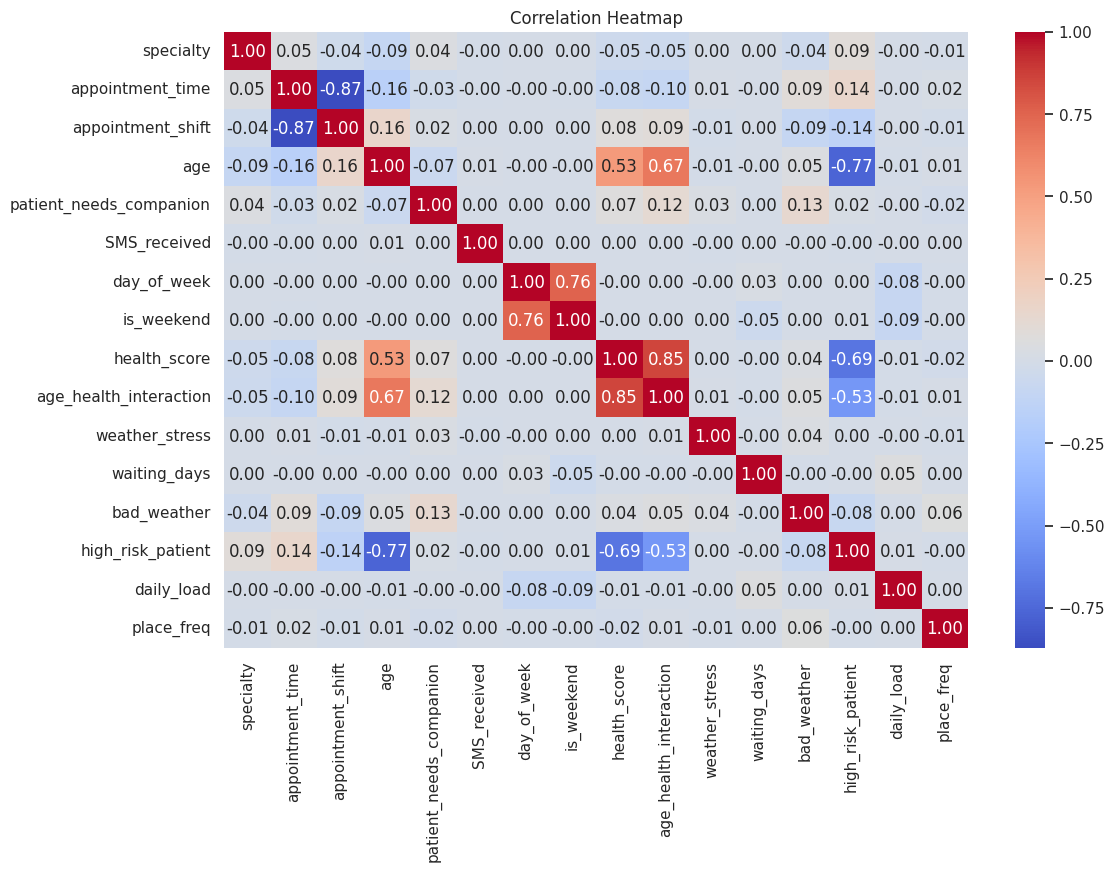

In [43]:
plt.figure(figsize=(12,8))
corr = df_model[['specialty','appointment_time','appointment_shift','age','patient_needs_companion',
                'SMS_received','day_of_week','is_weekend','health_score','age_health_interaction',
                'weather_stress','waiting_days','bad_weather','high_risk_patient','daily_load','place_freq']].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')  # Add annot=True, fmt='.2f'
plt.title("Correlation Heatmap")
plt.show()

**DEFINING X & y **

In [44]:
X = df_model.drop(columns=['no_show', 'appointment_date', 'appointment_date_continuous'])
y = df_model['no_show']

features = ['specialty', 'appointment_time', 'appointment_shift', 'age', 'patient_needs_companion',
                'SMS_received', 'day_of_week', 'is_weekend', 'health_score', 'age_health_interaction',
                'weather_stress', 'waiting_days', 'bad_weather', 'high_risk_patient','daily_load', 'place_freq']

X = X[features]

In [45]:
X = df_model.drop(columns=['no_show', 'appointment_date', 'appointment_date_continuous'])
y = df_model['no_show']

features = ['specialty', 'appointment_time', 'appointment_shift', 'age', 'patient_needs_companion',
                'SMS_received', 'weather_stress', 'bad_weather', 'high_risk_patient', 'place_freq']

X = X[features]

In [46]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=42)

In [47]:
# HANDLE IMBALANCE (SMOTE)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_sm.value_counts())

Before: no_show
0    59780
1    27865
Name: count, dtype: int64
After: no_show
0    59780
1    59780
Name: count, dtype: int64


In [48]:
X_train_sm.shape

(119560, 10)

**MODEL BUILDING** (NO-SHOW PREDICTION)





In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report,confusion_matrix
from sklearn.model_selection import StratifiedKFold

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [50]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [52]:
# MODEL 1 — LOGISTIC REGRESSION

lr = LogisticRegression(max_iter=3000, class_weight='balanced')

lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

F1 Score: 0.531032095346422
ROC-AUC: 0.6666298944167228
Confusion Matrix:
 [[7060 7886]
 [1597 5369]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.47      0.60     14946
           1       0.41      0.77      0.53      6966

    accuracy                           0.57     21912
   macro avg       0.61      0.62      0.56     21912
weighted avg       0.69      0.57      0.58     21912



In [53]:
# MODEL 2 — RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=18,
    min_samples_split=20,
    min_samples_leaf=2,
    max_features=0.7,
    class_weight='balanced',
    random_state=42,

)

rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

F1 Score: 0.587946344228226
ROC-AUC: 0.7526295304305184
Confusion Matrix:
 [[10701  4245]
 [ 2298  4668]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.72      0.77     14946
           1       0.52      0.67      0.59      6966

    accuracy                           0.70     21912
   macro avg       0.67      0.69      0.68     21912
weighted avg       0.73      0.70      0.71     21912



In [54]:
# MODEL 3 - GRADIENT BOOSTING

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train_sm, y_train_sm)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

F1 Score: 0.6098136352913422
ROC-AUC: 0.7467944798422373
Confusion Matrix:
 [[10126  4820]
 [ 1796  5170]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.68      0.75     14946
           1       0.52      0.74      0.61      6966

    accuracy                           0.70     21912
   macro avg       0.68      0.71      0.68     21912
weighted avg       0.74      0.70      0.71     21912



In [55]:
# MODEL 4 — XGBOOST

xgb = XGBClassifier(
    n_estimators=150,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    scale_pos_weight= 2.15,
    random_state=42,
    eval_metric='logloss'

)

xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

F1 Score: 0.6127774769897131
ROC-AUC: 0.7541129211683257
Confusion Matrix:
 [[9101 5845]
 [1307 5659]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.61      0.72     14946
           1       0.49      0.81      0.61      6966

    accuracy                           0.67     21912
   macro avg       0.68      0.71      0.67     21912
weighted avg       0.75      0.67      0.68     21912



In [56]:
# MODEL 5 — LIGHTGBM

lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    class_weight='balanced',
    random_state=42
)

lgb.fit(X_train_sm, y_train_sm)

y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:,1]

print("F1 Score:", f1_score(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 59780, number of negative: 59780
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 718
[LightGBM] [Info] Number of data points in the train set: 119560, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
F1 Score: 0.6056458511548332
ROC-AUC: 0.7545986299073641
Confusion Matrix:
 [[10502  4444]
 [ 2010  4956]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.70      0.76     14946
           1       0.53      0.71      0.61      6966

    accuracy                           0.71     21912
   macro avg       0.68      0.71      0.69     21912
weighted avg       0.74      0.71      0.71     21912



**COMPARE ALL MODELS**

In [57]:
results = pd.DataFrame({
    'Model': ['Logistic', 'RandomForest','GRADIENT BOOSTING', 'XGBoost', 'LightGBM'],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgb)
    ]
})

results.sort_values(by='F1 Score', ascending=False)

,Model,F1 Score,ROC-AUC
3,XGBoost,0.612777,0.754113
2,GRADIENT BOOSTING,0.609814,0.746794
4,LightGBM,0.605646,0.754599
1,RandomForest,0.587946,0.752630
0,Logistic,0.531032,0.666630


In [58]:
best_model = xgb

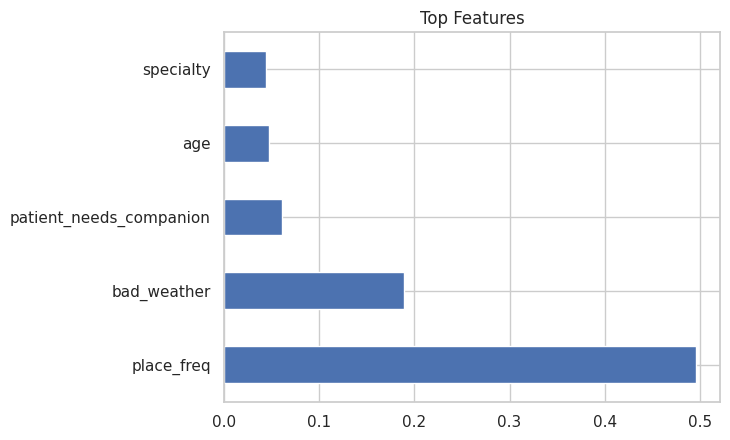

In [59]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(5).plot(kind='barh')

plt.title("Top Features")
plt.show()

In [60]:
# Save model
import joblib
joblib.dump(xgb, 'noshow_classifier_final.joblib')
print(" Model saved!")

 Model saved!


**DEMAND FORECASTING**

In [157]:
import pandas as pd
import numpy as np



In [158]:
df_forecast = df.copy()

# Create daily demand
daily_df = df_forecast.groupby('appointment_date_continuous').size().reset_index(name='y')
daily_df.columns = ['ds', 'y']

# Convert to datetime
daily_df['ds'] = pd.to_datetime(daily_df['ds'])

# Sort
daily_df = daily_df.sort_values('ds').reset_index(drop=True)

In [161]:
 # Time features
daily_df['dayofweek'] = daily_df['ds'].dt.dayofweek
daily_df['month'] = daily_df['ds'].dt.month

# Lag features
daily_df['lag_1'] = daily_df['y'].shift(1)
daily_df['lag_2'] = daily_df['y'].shift(2)
daily_df['lag_7'] = daily_df['y'].shift(7)

# Rolling feature
daily_df['rolling_7'] = daily_df['y'].shift(1).rolling(7).mean()

# Trend
daily_df['trend'] = np.arange(len(daily_df))

# Log transform (CRITICAL)
daily_df['y_log'] = np.log1p(daily_df['y'])

# Drop missing
daily_df = daily_df.dropna()

In [162]:
split_idx = int(len(daily_df) * 0.8)

train = daily_df.iloc[:split_idx]
test  = daily_df.iloc[split_idx:]

In [163]:
FEATURES = ['dayofweek', 'month', 'lag_1', 'lag_2', 'lag_7', 'rolling_7', 'trend']

In [164]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

xgb.fit(train[FEATURES], train['y_log'])

# Predict
xgb_pred_log = xgb.predict(test[FEATURES])

# Convert back
xgb_pred = np.expm1(xgb_pred_log)

In [165]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42
)

lgb.fit(train[FEATURES], train['y_log'])

# Predict
lgb_pred_log = lgb.predict(test[FEATURES])

# Convert back
lgb_pred = np.expm1(lgb_pred_log)

In [166]:
from prophet import Prophet

prophet = Prophet()

# Prophet uses original scale
prophet.fit(train[['ds', 'y']])

future = prophet.make_future_dataframe(periods=len(test))

forecast = prophet.predict(future)

prophet_pred = forecast.tail(len(test))['yhat'].values

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [167]:
from sklearn.metrics import mean_absolute_error, r2_score

def evaluate(name, y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    print(f"{name}")
    print("MAE:", round(mae,2))
    print("R2:", round(r2,3))
    print("MAPE:", round(mape,2), "%")
    print("-"*30)

    return mape

In [170]:
y_true = test['y']

mape_xgb = evaluate("XGBoost", y_true, xgb_pred)
mape_lgb = evaluate("LightGBM", y_true, lgb_pred)
mape_prophet = evaluate("Prophet", y_true, prophet_pred)

XGBoost
MAE: 135.69
R2: 0.23
MAPE: 1889.76 %
------------------------------
LightGBM
MAE: 156.75
R2: 0.167
MAPE: 2707.69 %
------------------------------
Prophet
MAE: 200.23
R2: -0.007
MAPE: 2824.6 %
------------------------------


In [171]:
results = {
    "XGBoost": mape_xgb,
    "LightGBM": mape_lgb,
    "Prophet": mape_prophet
}

best_model_name = min(results, key=results.get)

print("Best Model:", best_model_name)

Best Model: XGBoost


In [173]:
import joblib
joblib.dump(xgb, 'noshow_classifier_final.joblib')
print(" Model saved!")

 Model saved!


**Streamlit**